<a href="https://colab.research.google.com/github/Yahya1805/PCVK_GANJIL_2026/blob/main/Week5_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# PRAKTIKUM 5
## PENGOLAHAN CITRA DAN VISI KOMPUTER

Nama: M. Yahya Irvansyah
NIM: 244107020032
Kelas: TI-3G
No. Absen: 10

SyntaxError: invalid decimal literal (2173663513.py, line 6)

In [27]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(512, 512, 3)


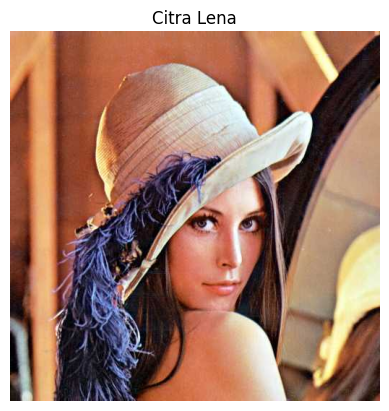

In [32]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

img = cv2.imread('/content/drive/MyDrive/PCVK/Pertemuan 5/lena.jpg')

print(img.shape)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Citra Lena')
plt.show()


In [33]:
height, width, depth = img.shape

red = np.zeros(256)
green = np.zeros(256)
blue = np.zeros(256)

for y in range(height):
    for x in range(width):
        blue[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        red[img[y][x][2]] += 1

print("Histogram berhasil dibuat")

Histogram berhasil dibuat


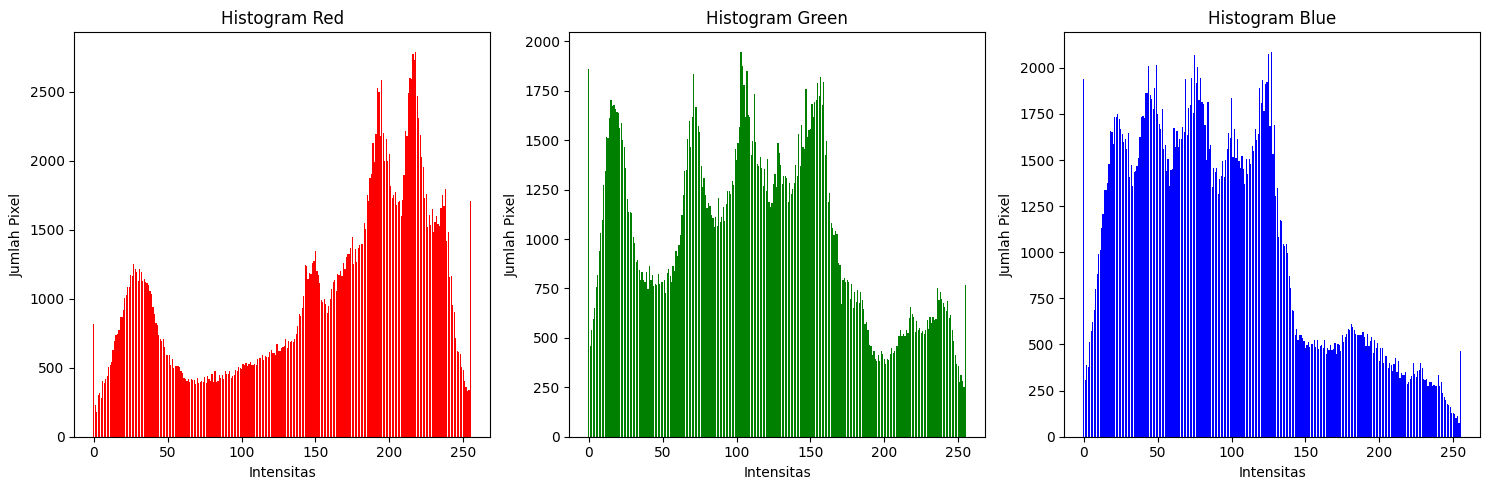

In [34]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.bar(range(256), red, color='red')
plt.title('Histogram Red')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')

plt.subplot(1, 3, 2)
plt.bar(range(256), green, color='green')
plt.title('Histogram Green')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')

plt.subplot(1, 3, 3)
plt.bar(range(256), blue, color='blue')
plt.title('Histogram Blue')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')

plt.tight_layout()
plt.show()

In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from google.colab import drive

# Konfigurasi Awal
FOLDER = '/content/drive/MyDrive/PCVK/Pertemuan 5'
NIM = '244107020032'  # Diisi sesuai NIM Anda

print("Import dan konfigurasi awal berhasil dilakukan.")

Import dan konfigurasi awal berhasil dilakukan.


In [36]:
import os

# Daftar file yang diperlukan
required_files = [
    'lena.jpg',
    'lena_lc.jpg',
    'KTM1a.jpg',
    'KTM1b.jpg',
    'KTM1c.jpg',
    'KTM1d.jpg'
]

print("=== PEMERIKSAAN KEBERADAAN FILE ===")
missing_files = []
for file in required_files:
    path = os.path.join(FOLDER, file)
    if os.path.exists(path):
        print(f"[ADA] {file}")
    else:
        print(f"[TIDAK ADA] {file}")
        missing_files.append(file)

if missing_files:
    print(f"\nPeringatan! File berikut tidak ditemukan: {missing_files}")
else:
    print("\nSemua file lengkap dan siap digunakan.")

=== PEMERIKSAAN KEBERADAAN FILE ===
[ADA] lena.jpg
[ADA] lena_lc.jpg
[ADA] KTM1a.jpg
[TIDAK ADA] KTM1b.jpg
[ADA] KTM1c.jpg
[ADA] KTM1d.jpg

Peringatan! File berikut tidak ditemukan: ['KTM1b.jpg']


In [45]:
def calc_manual_histogram(image):
    # Mendapatkan tinggi, lebar, dan jumlah channel dari citra
    # Menangani gambar grayscale maupun berwarna
    if len(image.shape) == 3:
        height, width, channels = image.shape
    else:
        height, width = image.shape
        channels = 1
        image = image[:, :, np.newaxis] # Ubah ke bentuk 3D agar loop seragam

    # Inisialisasi array kosong berukuran (256, channels)
    hist = np.zeros((256, channels))

    # Mengisi histogram secara manual
    for y in range(height):
        for x in range(width):
            for c in range(channels):
                intensity = image[y, x, c]
                hist[intensity, c] += 1

    return hist

In [46]:
# Membaca gambar Lena
lena_path = os.path.join(FOLDER, 'lena.jpg')
img_lena = cv2.imread(lena_path)

# 1. Metode Manual
hist_manual_lena = calc_manual_histogram(img_lena)

# 2. Metode NumPy
# Di NumPy, kita pisahkan channel-nya terlebih dahulu
hist_numpy_lena = np.zeros((256, 3))
for c in range(3):
    # np.histogram mengembalikan histogram dan bin_edges
    hist, _ = np.histogram(img_lena[:, :, c], bins=256, range=(0, 256))
    hist_numpy_lena[:, c] = hist

# 3. Metode OpenCV (cv2.calcHist)
hist_cv2_lena = np.zeros((256, 3))
for c in range(3):
    hist = cv2.calcHist([img_lena], [c], None, [256], [0, 256])
    hist_cv2_lena[:, c] = hist.flatten()

print("Pembuatan histogram Lena dengan 3 metode selesai.")

Pembuatan histogram Lena dengan 3 metode selesai.


In [47]:
channels_name = ['Blue', 'Green', 'Red'] # OpenCV menggunakan format BGR

print(f"=== PEMBUKTIAN SELISIH MAKSIMUM LENA.JPG (NIM: {NIM}) ===\n")

all_zero_lena = True
for c in range(3):
    diff_man_num = np.max(np.abs(hist_manual_lena[:, c] - hist_numpy_lena[:, c]))
    diff_man_cv = np.max(np.abs(hist_manual_lena[:, c] - hist_cv2_lena[:, c]))
    diff_num_cv = np.max(np.abs(hist_numpy_lena[:, c] - hist_cv2_lena[:, c]))

    print(f"Channel {channels_name[c]}:")
    print(f"  Manual vs NumPy = {diff_man_num}")
    print(f"  Manual vs cv.calcHist = {diff_man_cv}")
    print(f"  NumPy vs cv.calcHist = {diff_num_cv}\n")

    if diff_man_num != 0 or diff_man_cv != 0 or diff_num_cv != 0:
        all_zero_lena = False

if all_zero_lena:
    print("KESIMPULAN LENA: SELURUH SELISIH MAKSIMUM BERNILAI 0 (TERBUKTI SAMA)")
else:
    print("KESIMPULAN LENA: Terdapat perbedaan hasil pada metode histogram.")

=== PEMBUKTIAN SELISIH MAKSIMUM LENA.JPG (NIM: 244107020032) ===

Channel Blue:
  Manual vs NumPy = 0.0
  Manual vs cv.calcHist = 0.0
  NumPy vs cv.calcHist = 0.0

Channel Green:
  Manual vs NumPy = 0.0
  Manual vs cv.calcHist = 0.0
  NumPy vs cv.calcHist = 0.0

Channel Red:
  Manual vs NumPy = 0.0
  Manual vs cv.calcHist = 0.0
  NumPy vs cv.calcHist = 0.0

KESIMPULAN LENA: SELURUH SELISIH MAKSIMUM BERNILAI 0 (TERBUKTI SAMA)


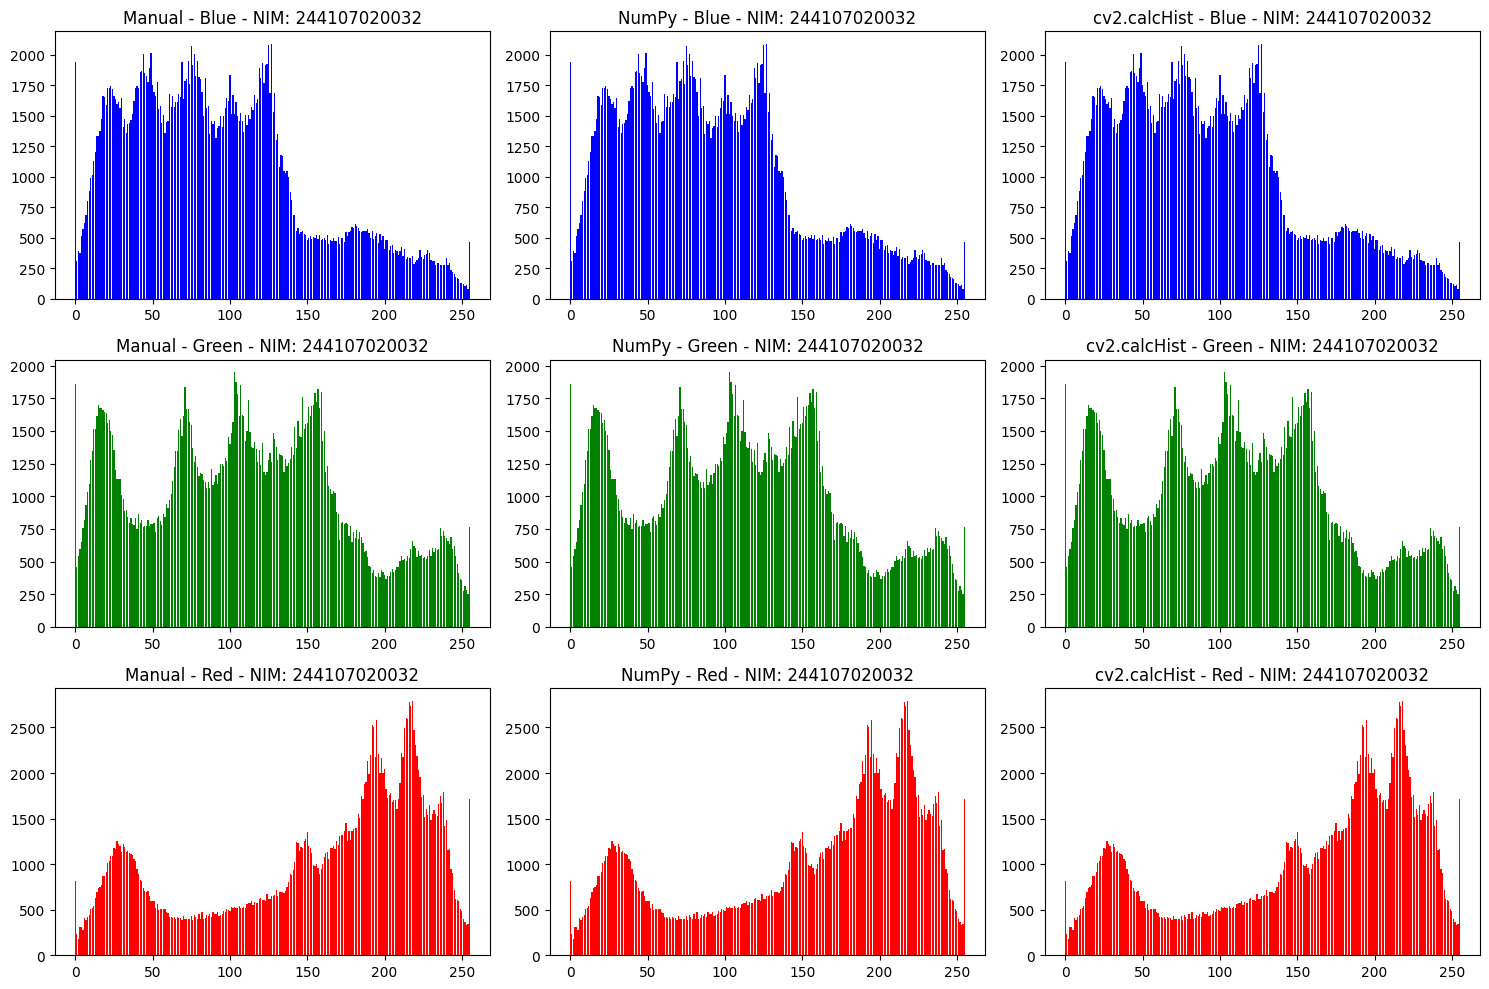

In [40]:
# Plot visualisasi perbandingan histogram untuk Lena.jpg
plt.figure(figsize=(15, 10))
colors = ['blue', 'green', 'red']

for c in range(3):
    plt.subplot(3, 3, c*3 + 1)
    plt.bar(range(256), hist_manual_lena[:, c], color=colors[c])
    plt.title(f"Manual - {channels_name[c]} - NIM: {NIM}")

    plt.subplot(3, 3, c*3 + 2)
    plt.bar(range(256), hist_numpy_lena[:, c], color=colors[c])
    plt.title(f"NumPy - {channels_name[c]} - NIM: {NIM}")

    plt.subplot(3, 3, c*3 + 3)
    plt.bar(range(256), hist_cv2_lena[:, c], color=colors[c])
    plt.title(f"cv2.calcHist - {channels_name[c]} - NIM: {NIM}")

plt.tight_layout()
plt.show()

In [49]:
# Membaca gambar KTM1b
ktm_path = os.path.join(FOLDER, 'tilKTM1b.jpg')
img_ktm = cv2.imread(ktm_path)

if img_ktm is None:
    print("[PERINGATAN] File KTM1b.jpg tidak ditemukan di Drive! Lewati pembuatan histogram.")
    hist_manual_ktm = None
    hist_numpy_ktm = None
    hist_cv2_ktm = None
else:
    # 1. Metode Manual
    hist_manual_ktm = calc_manual_histogram(img_ktm)

    # 2. Metode NumPy
    hist_numpy_ktm = np.zeros((256, 3))
    for c in range(3):
        hist, _ = np.histogram(img_ktm[:, :, c], bins=256, range=(0, 256))
        hist_numpy_ktm[:, c] = hist

    # 3. Metode OpenCV (cv2.calcHist)
    hist_cv2_ktm = np.zeros((256, 3))
    for c in range(3):
        hist = cv2.calcHist([img_ktm], [c], None, [256], [0, 256])
        hist_cv2_ktm[:, c] = hist.flatten()
    print("Pembuatan histogram KTM1b dengan 3 metode selesai.")

Pembuatan histogram KTM1b dengan 3 metode selesai.


In [50]:
print(f"=== PEMBUKTIAN SELISIH MAKSIMUM KTM1B.JPG (NIM: {NIM}) ===\n")

if img_ktm is None:
    print("Pengujian dibatalkan karena file KTM1b.jpg tidak ditemukan.")
else:
    all_zero_ktm = True
    for c in range(3):
        diff_man_num = np.max(np.abs(hist_manual_ktm[:, c] - hist_numpy_ktm[:, c]))
        diff_man_cv = np.max(np.abs(hist_manual_ktm[:, c] - hist_cv2_ktm[:, c]))
        diff_num_cv = np.max(np.abs(hist_numpy_ktm[:, c] - hist_cv2_ktm[:, c]))

        print(f"Channel {channels_name[c]}:")
        print(f"  Manual vs NumPy = {diff_man_num}")
        print(f"  Manual vs cv.calcHist = {diff_man_cv}")
        print(f"  NumPy vs cv.calcHist = {diff_num_cv}\n")

        if diff_man_num != 0 or diff_man_cv != 0 or diff_num_cv != 0:
            all_zero_ktm = False

    if all_zero_ktm:
        print("KESIMPULAN KTM1B: SELURUH SELISIH MAKSIMUM BERNILAI 0 (TERBUKTI SAMA)")
    else:
        print("KESIMPULAN KTM1B: Terdapat perbedaan hasil pada metode histogram.")

=== PEMBUKTIAN SELISIH MAKSIMUM KTM1B.JPG (NIM: 244107020032) ===

Channel Blue:
  Manual vs NumPy = 0.0
  Manual vs cv.calcHist = 0.0
  NumPy vs cv.calcHist = 0.0

Channel Green:
  Manual vs NumPy = 0.0
  Manual vs cv.calcHist = 0.0
  NumPy vs cv.calcHist = 0.0

Channel Red:
  Manual vs NumPy = 0.0
  Manual vs cv.calcHist = 0.0
  NumPy vs cv.calcHist = 0.0

KESIMPULAN KTM1B: SELURUH SELISIH MAKSIMUM BERNILAI 0 (TERBUKTI SAMA)


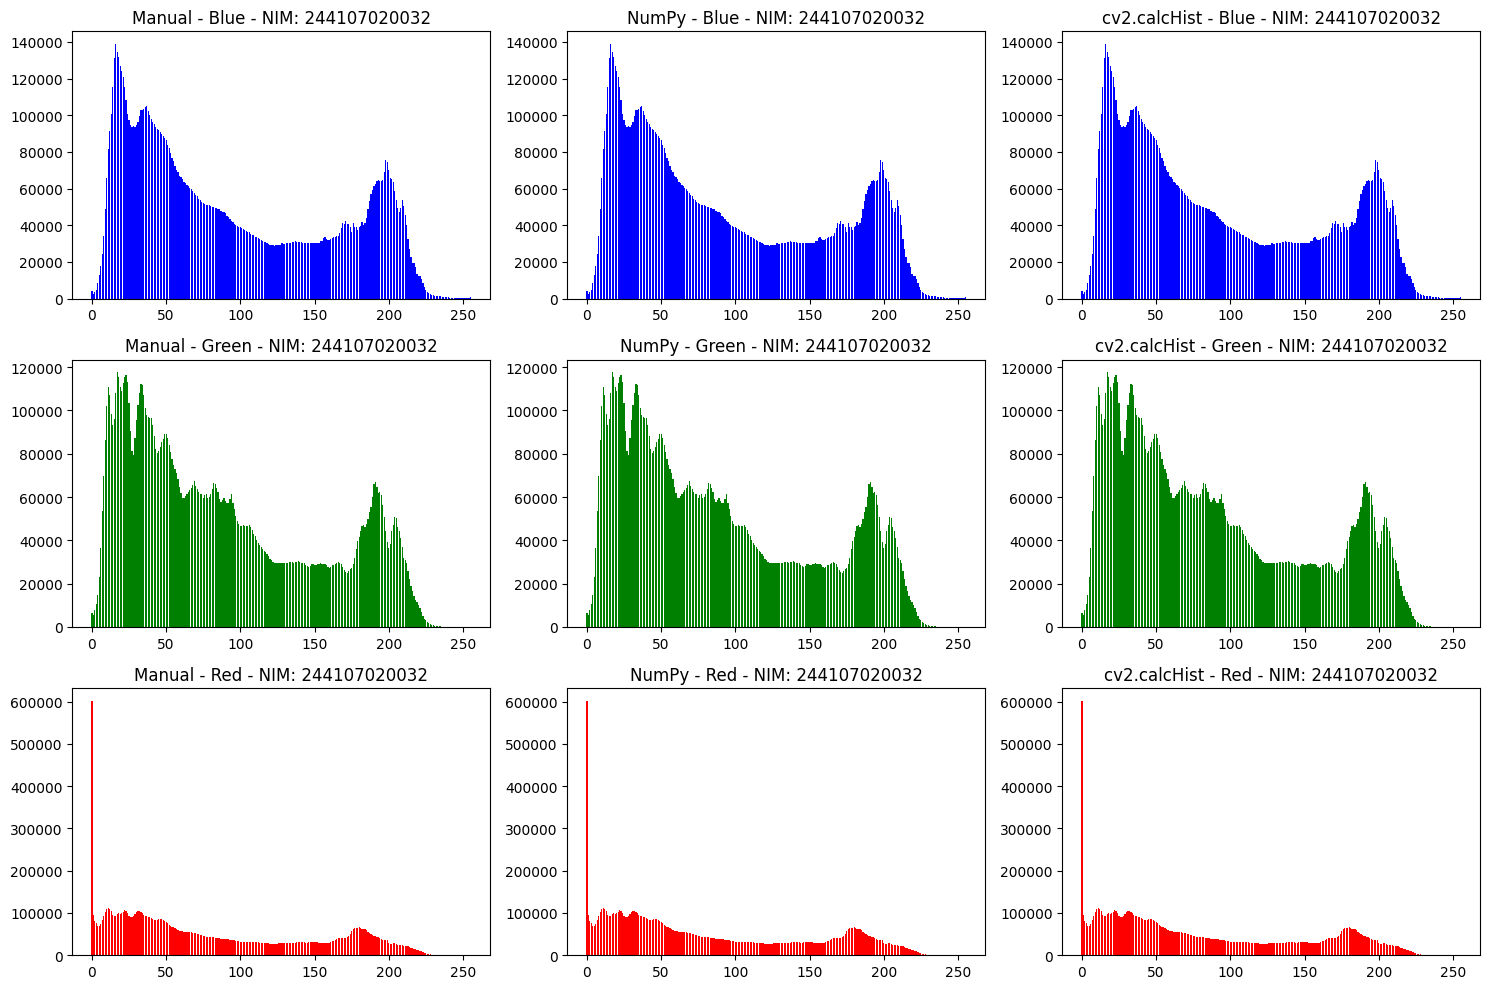

In [51]:
# Plot visualisasi perbandingan histogram untuk KTM1b.jpg
if img_ktm is None:
    print("Plot visualisasi KTM1b dilewati karena file tidak ditemukan.")
else:
    plt.figure(figsize=(15, 10))
    for c in range(3):
        plt.subplot(3, 3, c*3 + 1)
        plt.bar(range(256), hist_manual_ktm[:, c], color=colors[c])
        plt.title(f"Manual - {channels_name[c]} - NIM: {NIM}")

        plt.subplot(3, 3, c*3 + 2)
        plt.bar(range(256), hist_numpy_ktm[:, c], color=colors[c])
        plt.title(f"NumPy - {channels_name[c]} - NIM: {NIM}")

        plt.subplot(3, 3, c*3 + 3)
        plt.bar(range(256), hist_cv2_ktm[:, c], color=colors[c])
        plt.title(f"cv2.calcHist - {channels_name[c]} - NIM: {NIM}")
    plt.tight_layout()
    plt.show()

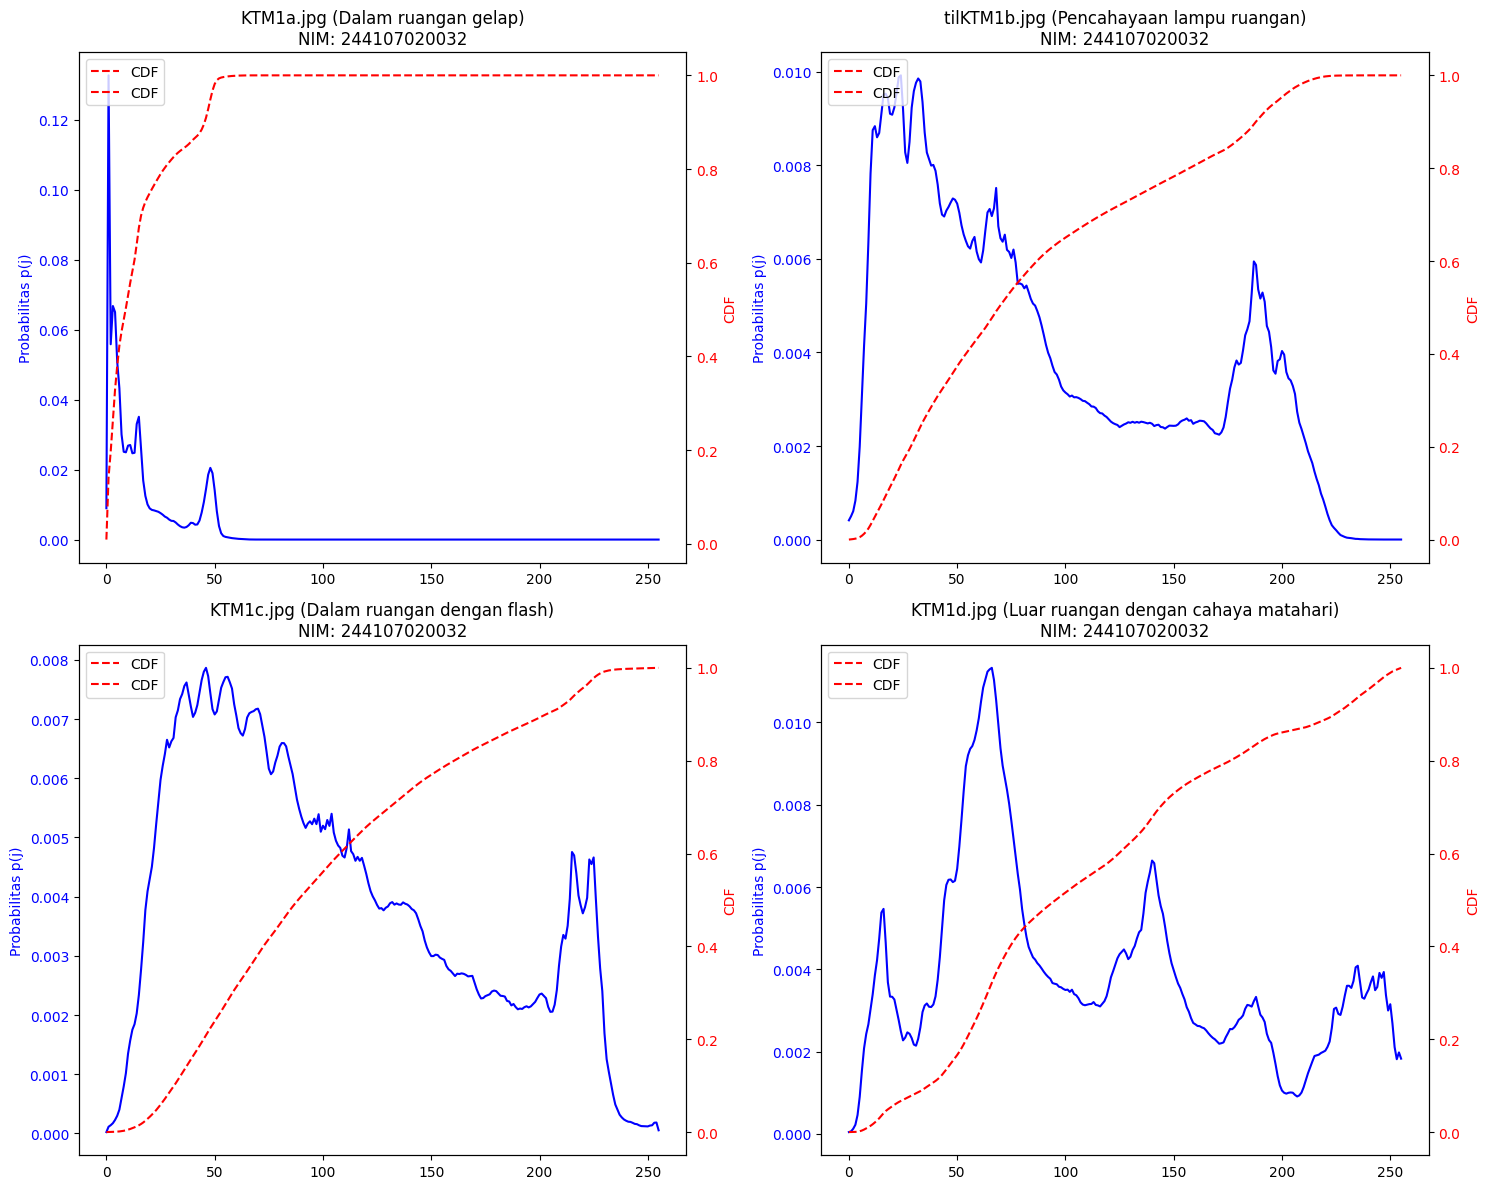

In [53]:
# ==================================================
# PERCOBAAN 2: Histogram Ternormalisasi p(j) dan CDF
# ==================================================

files_ktm = {
    'KTM1a.jpg': 'Dalam ruangan gelap',
    'tilKTM1b.jpg': 'Pencahayaan lampu ruangan',
    'KTM1c.jpg': 'Dalam ruangan dengan flash',
    'KTM1d.jpg': 'Luar ruangan dengan cahaya matahari'
}

plt.figure(figsize=(15, 12))
idx = 1

stats_info = {}

for filename, lighting in files_ktm.items():
    path = os.path.join(FOLDER, filename)
    plt.subplot(2, 2, idx)

    if not os.path.exists(path):
        plt.text(0.5, 0.5, f"{filename} Tidak Ditemukan", ha='center', va='center')
        plt.title(f"{filename} ({lighting}) - NIM: {NIM}")
        idx += 1
        continue

    # 1. Baca Citra & 2. Konversi ke Grayscale
    img_gray = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    # Hitung Statistik Intensitas
    mean_val = np.mean(img_gray)
    min_val = np.min(img_gray)
    max_val = np.max(img_gray)
    stats_info[filename] = (mean_val, min_val, max_val, lighting)

    # 3. Hitung Histogram 256 bin
    hist, _ = np.histogram(img_gray, bins=256, range=(0, 256))

    # 4. Normalisasi Histogram p(j)
    pj = hist / img_gray.size

    # 5. Hitung CDF menggunakan Cumulative Sum
    cdf = np.cumsum(pj)

    # Plot p(j) dan CDF
    plt.plot(range(256), pj, color='blue', label='p(j) (Normalized Hist)')
    plt.ylabel('Probabilitas p(j)', color='blue')
    plt.tick_params(axis='y', labelcolor='blue')

    # Sumbu kembar untuk CDF
    ax2 = plt.twinx()
    ax2.plot(range(256), cdf, color='red', linestyle='--', label='CDF')
    ax2.set_ylabel('CDF', color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    # Gabungkan legend
    lines, labels = plt.gca().get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper left')

    plt.title(f"{filename} ({lighting})\nNIM: {NIM}")
    plt.xlabel('Intensitas Piksel')
    idx += 1

plt.tight_layout()
plt.show()

In [54]:
print(f"=== STATISTIK INTENSITAS CITRA KTM (NIM: {NIM}) ===\n")
for filename, stats in stats_info.items():
    mean_v, min_v, max_v, lighting = stats
    print(f"File: {filename} ({lighting})")
    print(f"  - Rata-rata Intensitas: {mean_v:.2f}")
    print(f"  - Intensitas Minimum  : {min_v}")
    print(f"  - Intensitas Maksimum  : {max_v}\n")

=== STATISTIK INTENSITAS CITRA KTM (NIM: 244107020032) ===

File: KTM1a.jpg (Dalam ruangan gelap)
  - Rata-rata Intensitas: 15.16
  - Intensitas Minimum  : 0
  - Intensitas Maksimum  : 84

File: tilKTM1b.jpg (Pencahayaan lampu ruangan)
  - Rata-rata Intensitas: 87.24
  - Intensitas Minimum  : 0
  - Intensitas Maksimum  : 255

File: KTM1c.jpg (Dalam ruangan dengan flash)
  - Rata-rata Intensitas: 102.39
  - Intensitas Minimum  : 0
  - Intensitas Maksimum  : 255

File: KTM1d.jpg (Luar ruangan dengan cahaya matahari)
  - Rata-rata Intensitas: 112.31
  - Intensitas Minimum  : 0
  - Intensitas Maksimum  : 255



### Analisis Hasil Percobaan 2

Berdasarkan pengujian statistik intensitas piksel dan visualisasi kurva CDF pada citra KTM1a sampai KTM1d, kita dapat menarik kesimpulan berikut:

1. **Citra Paling Gelap vs. Citra Paling Terang**:
   - **Citra Paling Gelap** ditandai oleh nilai rata-rata intensitas (*mean*) yang paling rendah. Nilai pikselnya menumpuk di area kiri histogram (mendekati 0). Pada grafik, kurva CDF untuk citra gelap ini akan **menanjak sangat cepat secara curam di bagian awal (intensitas rendah)** dan langsung mendatar (mencapai nilai 1.0) jauh sebelum menyentuh nilai intensitas 255.
   - **Citra Paling Terang** ditandai oleh nilai rata-rata intensitas yang paling tinggi. Nilai pikselnya lebih banyak tersebar di area kanan histogram (mendekati 255). Pada grafik, kurva CDF untuk citra terang akan **menanjak secara lambat/landai di bagian awal**, lalu baru mulai menanjak tajam di area intensitas menengah hingga tinggi.

2. **Hubungan dengan Kondisi Akuisisi**:
   - Kondisi pencahayaan sangat memengaruhi sebaran intensitas piksel. Citra di dalam ruangan gelap memiliki nilai piksel yang sangat rendah karena minimnya foton cahaya yang mengenai sensor kamera saat pengambilan gambar.
   - Sebaliknya, penggunaan *flash* atau cahaya matahari langsung (luar ruangan) memberikan suplai cahaya yang melimpah, menggeser distribusi probabilitas piksel $p(j)$ ke arah intensitas yang lebih tinggi, sehingga menghasilkan kurva CDF yang lebih landai di awal dan baru mencapai titik jenuh (1.0) di ujung kanan skala keabuan.

In [55]:
# ==================================================
# PERCOBAAN 3: Pengaruh Jumlah Bin
# ==================================================

# Mengecek apakah variabel PARAM tersedia di environment
if 'PARAM' not in globals() or 'bins' not in PARAM:
    # Buat nilai fallback agar notebook aman dan tidak gagal
    print("[INFO] Variabel PARAM['bins'] belum didefinisikan oleh jobsheet. Menggunakan nilai fallback bins = 32 untuk demonstrasi.")
    bins_param = 32
else:
    bins_param = PARAM['bins']

ktm_b_path = os.path.join(FOLDER, 'KTM1b.jpg')

if not os.path.exists(ktm_b_path):
    print("[PERINGATAN] File KTM1b.jpg tidak ditemukan. Tidak dapat menampilkan perbandingan bin untuk KTM1b.")
else:
    img_ktm_b_gray = cv2.imread(ktm_b_path, cv2.IMREAD_GRAYSCALE)

    plt.figure(figsize=(15, 5))

    # Subplot 1: Histogram dengan bins_param
    plt.subplot(1, 2, 1)
    hist_reduced, bin_edges_reduced = np.histogram(img_ktm_b_gray, bins=bins_param, range=(0, 256))
    plt.bar(bin_edges_reduced[:-1], hist_reduced, width=(256/bins_param), color='purple', edgecolor='black', align='edge')
    plt.title(f"Histogram {bins_param} Bins (NIM: {NIM})")
    plt.xlabel('Intensitas')
    plt.ylabel('Jumlah Pixel')
    plt.xlim(0, 256)

    # Subplot 2: Histogram dengan 256 bins
    plt.subplot(1, 2, 2)
    hist_256, bin_edges_256 = np.histogram(img_ktm_b_gray, bins=256, range=(0, 256))
    plt.bar(bin_edges_256[:-1], hist_256, width=1.0, color='gray', edgecolor='none', align='edge')
    plt.title(f"Histogram 256 Bins (NIM: {NIM})")
    plt.xlabel('Intensitas')
    plt.ylabel('Jumlah Pixel')
    plt.xlim(0, 256)

    plt.suptitle(f"Perbandingan Pengaruh Jumlah Bin pada KTM1b.jpg - NIM: {NIM}")
    plt.tight_layout()
    plt.show()

[INFO] Variabel PARAM['bins'] belum didefinisikan oleh jobsheet. Menggunakan nilai fallback bins = 32 untuk demonstrasi.
[PERINGATAN] File KTM1b.jpg tidak ditemukan. Tidak dapat menampilkan perbandingan bin untuk KTM1b.


### Analisis dan Penjelasan Percobaan 3

- **Perbedaan Histogram**:
  Histogram dengan jumlah bin sedikit (misalnya 32 bin) terlihat seperti diagram batang yang \lebar-lebar dan kasar, sedangkan histogram 256 bin terlihat sangat halus dan berkesinambungan mencakup setiap tingkat intensitas dari 0 hingga 255.
  
- **Informasi yang Hilang**:
  Saat jumlah bin dikurangi, kita kehilangan detail transisi atau fluktuasi intensitas piksel yang spesifik. Beberapa nilai keabuan yang bertetangga dipaksa untuk masuk ke dalam satu kelompok (*bin*) yang sama.
  
- **Kesimpulan Pengurangan Bin**:
  Pengurangan jumlah bin mereduksi resolusi histogram dengan cara menggabungkan beberapa rentang intensitas menjadi satu kelompok tunggal. Akibatnya, rincian distribusi frekuensi piksel yang bernilai halus (*fine details*) menjadi hilang, menyisakan gambaran distribusi yang sangat umum atau kasar saja.

In [ ]:
# ------------ E-2 PERCOBAAN HISTOGRAM EQUALIZATION ---------------



In [56]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Memastikan konfigurasi dasar tersedia
FOLDER = '/content/drive/MyDrive/PCVK/Pertemuan 5'
NIM = '244107020032'

print(f"Konfigurasi E-2 berhasil dimuat. NIM: {NIM}")

Konfigurasi E-2 berhasil dimuat. NIM: 244107020032


In [57]:
def manual_equalize(gray_img):
    # 1. Hitung frekuensi kemunculan setiap intensitas (histogram)
    hist_before = np.zeros(256, dtype=np.int32)
    height, width = gray_img.shape
    total_pixels = height * width

    for y in range(height):
        for x in range(width):
            hist_before[gray_img[y, x]] += 1

    # 2. Hitung frekuensi kumulatif (CDF)
    cdf = np.zeros(256, dtype=np.int32)
    cumulative_sum = 0
    for i in range(256):
        cumulative_sum += hist_before[i]
        cdf[i] = cumulative_sum

    # 3. Normalisasi kumulatif histogram & hitung lookup table
    # s = round((L - 1) * CDF_normalized)
    lut = np.zeros(256, dtype=np.uint8)
    for i in range(256):
        lut[i] = np.round(255 * (cdf[i] / total_pixels))

    # 4. Terapkan lookup table ke citra
    equalized_img = np.zeros_like(gray_img)
    for y in range(height):
        for x in range(width):
            equalized_img[y, x] = lut[gray_img[y, x]]

    # 5. Hitung histogram hasil
    hist_after = np.zeros(256, dtype=np.int32)
    for y in range(height):
        for x in range(width):
            hist_after[equalized_img[y, x]] += 1

    return equalized_img, hist_before, hist_after, cdf, lut

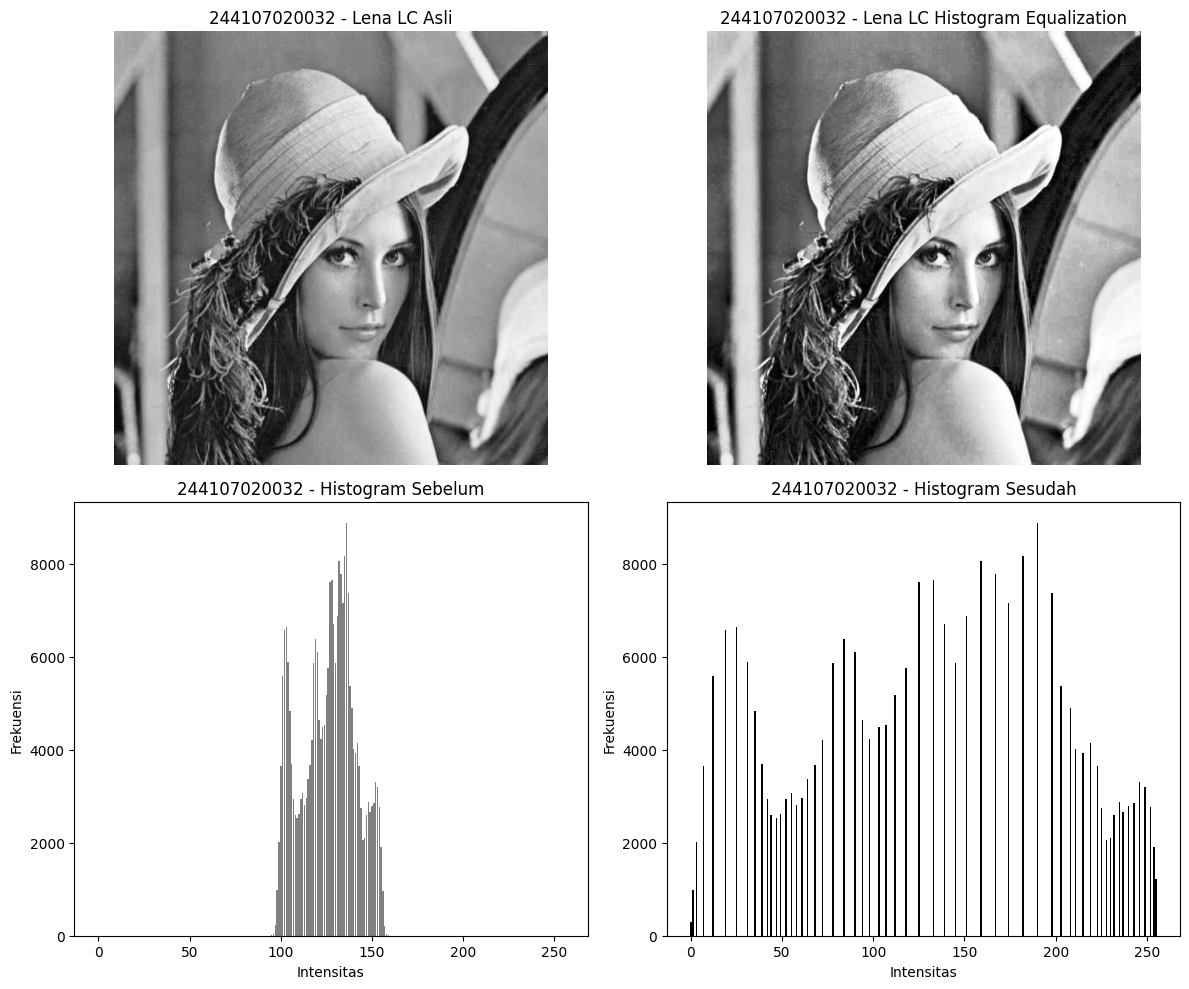

In [58]:
# TAHAP 1: lena_lc.jpg
lena_lc_path = os.path.join(FOLDER, 'lena_lc.jpg')

if not os.path.exists(lena_lc_path):
    print(f"[PERINGATAN] File tidak ditemukan: {lena_lc_path}")
else:
    img_lena_lc = cv.imread(lena_lc_path, cv.IMREAD_GRAYSCALE)
    img_lena_lc_eq, hist_orig, hist_eq, cdf, lut = manual_equalize(img_lena_lc)

    # Tampilan visualisasi 2x2
    plt.figure(figsize=(12, 10))

    plt.subplot(2, 2, 1)
    plt.imshow(img_lena_lc, cmap='gray')
    plt.title(f"{NIM} - Lena LC Asli")
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.imshow(img_lena_lc_eq, cmap='gray')
    plt.title(f"{NIM} - Lena LC Histogram Equalization")
    plt.axis('off')

    plt.subplot(2, 2, 3)
    plt.bar(range(256), hist_orig, color='gray')
    plt.title(f"{NIM} - Histogram Sebelum")
    plt.xlabel('Intensitas')
    plt.ylabel('Frekuensi')

    plt.subplot(2, 2, 4)
    plt.bar(range(256), hist_eq, color='black')
    plt.title(f"{NIM} - Histogram Sesudah")
    plt.xlabel('Intensitas')
    plt.ylabel('Frekuensi')

    plt.tight_layout()
    plt.show()

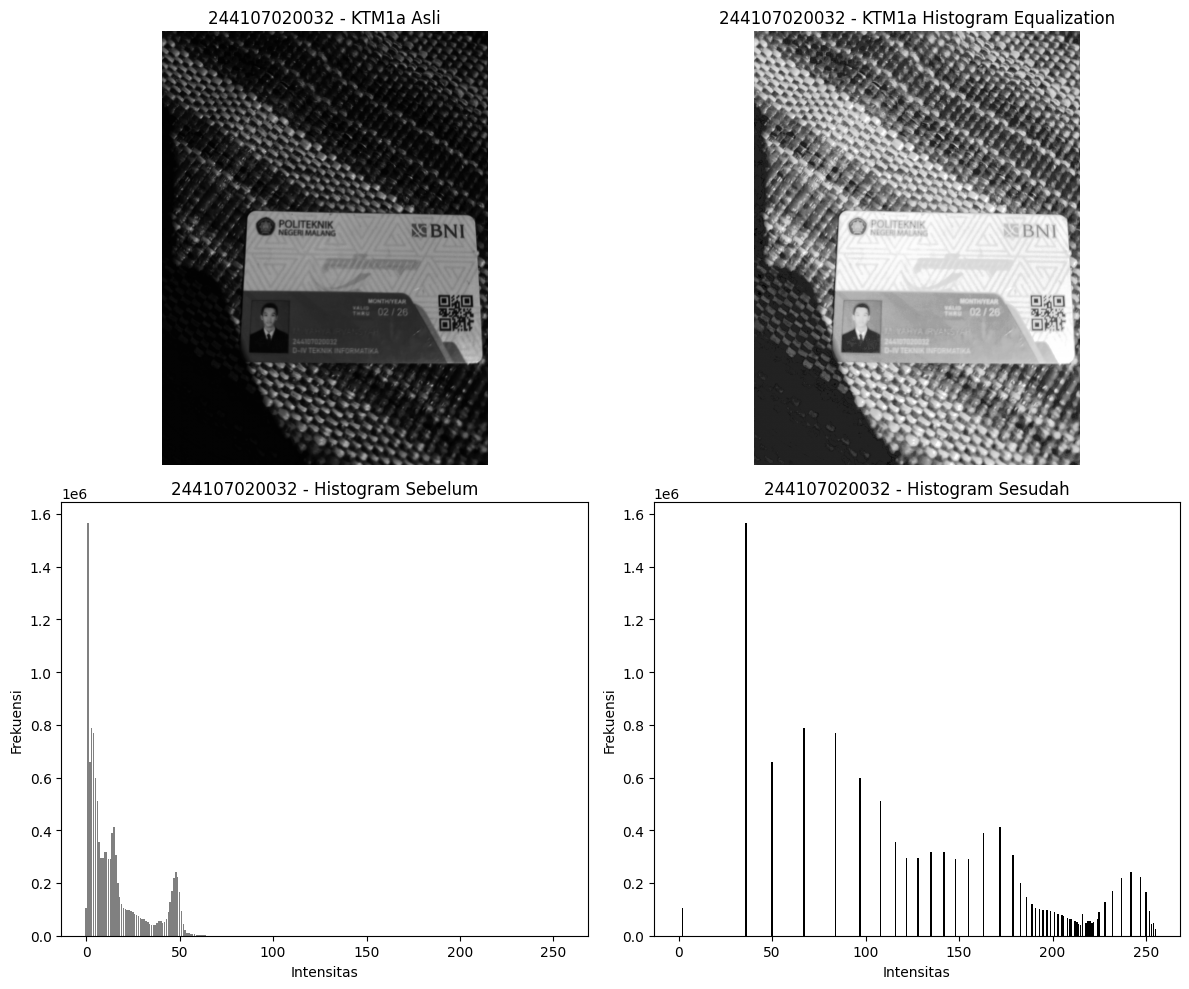

In [59]:
# TAHAP 2: KTM1a.jpg
ktm1a_path = os.path.join(FOLDER, 'KTM1a.jpg')

if not os.path.exists(ktm1a_path):
    print(f"[PERINGATAN] File tidak ditemukan: {ktm1a_path}")
else:
    img_ktm1a = cv.imread(ktm1a_path, cv.IMREAD_GRAYSCALE)
    img_ktm1a_eq, hist_ktm_orig, hist_ktm_eq, _, _ = manual_equalize(img_ktm1a)

    # Tampilan visualisasi 2x2
    plt.figure(figsize=(12, 10))

    plt.subplot(2, 2, 1)
    plt.imshow(img_ktm1a, cmap='gray')
    plt.title(f"{NIM} - KTM1a Asli")
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.imshow(img_ktm1a_eq, cmap='gray')
    plt.title(f"{NIM} - KTM1a Histogram Equalization")
    plt.axis('off')

    plt.subplot(2, 2, 3)
    plt.bar(range(256), hist_ktm_orig, color='gray')
    plt.title(f"{NIM} - Histogram Sebelum")
    plt.xlabel('Intensitas')
    plt.ylabel('Frekuensi')

    plt.subplot(2, 2, 4)
    plt.bar(range(256), hist_ktm_eq, color='black')
    plt.title(f"{NIM} - Histogram Sesudah")
    plt.xlabel('Intensitas')
    plt.ylabel('Frekuensi')

    plt.tight_layout()
    plt.show()

In [60]:
# PERCOBAAN 2: Perbandingan Manual vs cv.equalizeHist()
print(f"=== PERBANDINGAN MANUAL VS OPENCV (NIM: {NIM}) ===\n")

# Lena LC
if os.path.exists(lena_lc_path):
    cv_lena_lc_eq = cv.equalizeHist(img_lena_lc)
    diff_lena = np.max(np.abs(img_lena_lc_eq.astype(np.int16) - cv_lena_lc_eq.astype(np.int16)))
    print(f"LENA_LC.JPG")
    print(f"  Selisih maksimum manual vs cv.equalizeHist = {diff_lena}")
else:
    diff_lena = None
    print("File LENA_LC.JPG tidak tersedia.")

# KTM1a
if os.path.exists(ktm1a_path):
    cv_ktm1a_eq = cv.equalizeHist(img_ktm1a)
    diff_ktm1a = np.max(np.abs(img_ktm1a_eq.astype(np.int16) - cv_ktm1a_eq.astype(np.int16)))
    print(f"\nKTM1A.JPG")
    print(f"  Selisih maksimum manual vs cv.equalizeHist = {diff_ktm1a}")
else:
    diff_ktm1a = None
    print("File KTM1A.JPG tidak tersedia.")

=== PERBANDINGAN MANUAL VS OPENCV (NIM: 244107020032) ===

LENA_LC.JPG
  Selisih maksimum manual vs cv.equalizeHist = 0

KTM1A.JPG
  Selisih maksimum manual vs cv.equalizeHist = 2


### Analisis Perbedaan Hasil Manual vs OpenCV

Jika terdapat perbedaan nilai selisih antara hasil manual dan `cv.equalizeHist` yang bernilai bukan nol (biasanya berkisar 1 hingga beberapa tingkat intensitas), hal tersebut disebabkan oleh perbedaan teknis dalam proses kalkulasi:
1. **Penanganan Nilai Minimum CDF**: OpenCV mengabaikan atau menormalisasi nilai minimum CDF secara berbeda agar tingkat keabuan terendah tidak langsung dipetakan ke 0 secara ekstrem.
2. **Pembulatan (Rounding)**: Fungsi manual kami menggunakan `np.round`, sedangkan OpenCV menggunakan metode pembulatan internal atau *floor* numerik tertentu saat memetakan skala warna $L-1$ (yaitu 255).
3. **Optimasi Struktur Array**: OpenCV diimplementasikan menggunakan lookup table yang sangat dioptimasi pada tingkat bahasa C, yang terkadang memiliki penanganan presisi floating point yang sedikit berbeda dari representasi Python standar.

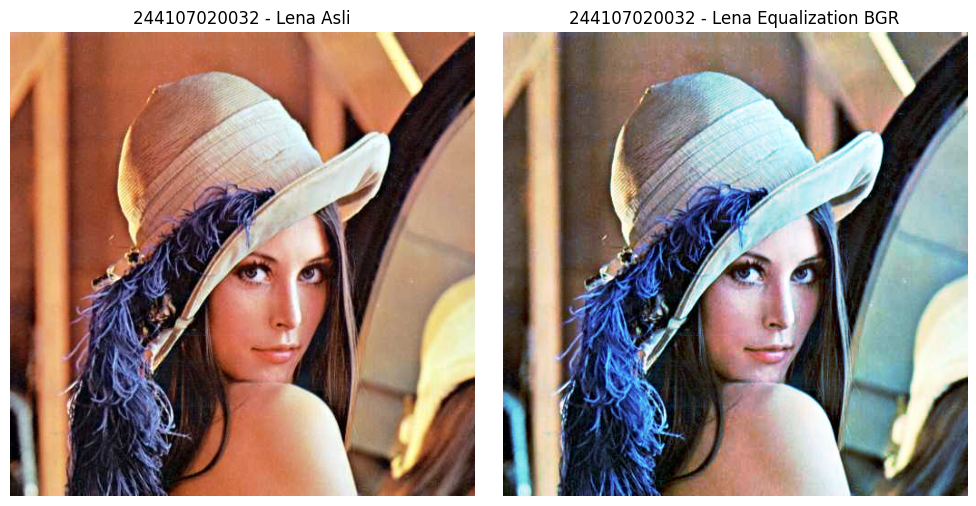

In [61]:
# PERCOBAAN 3: Equalization Citra Berwarna
def equalize_bgr_channels(bgr_img):
    channels = list(cv.split(bgr_img))
    for i in range(3):
        channels[i] = cv.equalizeHist(channels[i])
    return cv.merge(channels)

lena_path = os.path.join(FOLDER, 'lena.jpg')
if not os.path.exists(lena_path):
    print(f"[PERINGATAN] File tidak ditemukan: {lena_path}")
else:
    img_lena_color = cv.imread(lena_path)
    img_lena_bgr_eq = equalize_bgr_channels(img_lena_color)

    # Menampilkan lena sebelum dan sesudah
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(cv.cvtColor(img_lena_color, cv.COLOR_BGR2RGB))
    plt.title(f"{NIM} - Lena Asli")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv.cvtColor(img_lena_bgr_eq, cv.COLOR_BGR2RGB))
    plt.title(f"{NIM} - Lena Equalization BGR")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

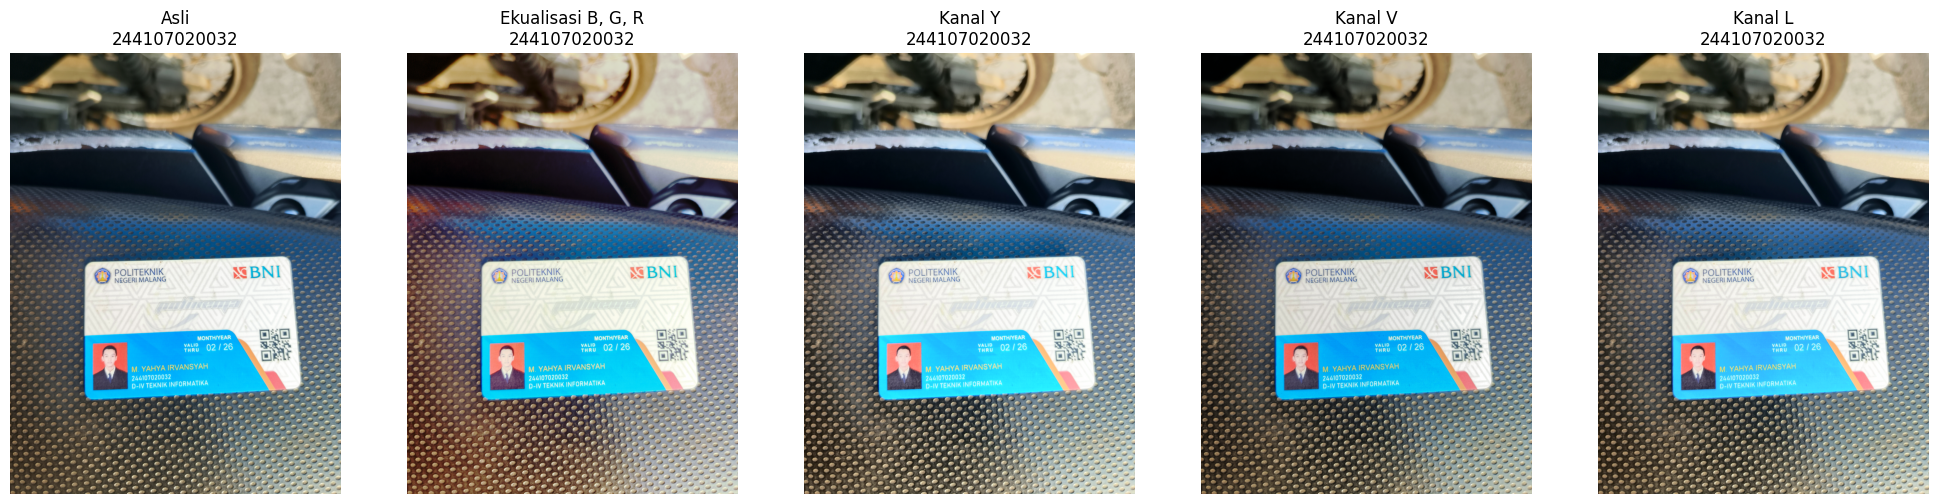

In [62]:
# KTM1d.jpg - Implementasi 5 Metode Berbeda
ktm1d_path = os.path.join(FOLDER, 'KTM1d.jpg')

if not os.path.exists(ktm1d_path):
    print(f"[PERINGATAN] File tidak ditemukan: {ktm1d_path}")
else:
    img_ktm1d = cv.imread(ktm1d_path)

    # 1. Asli
    # 2. Ekualisasi B, G, R
    he_bgr = equalize_bgr_channels(img_ktm1d)

    # 3. YCrCb (Kanal Y)
    ycrcb = cv.cvtColor(img_ktm1d, cv.COLOR_BGR2YCrCb)
    y, cr, cb = cv.split(ycrcb)
    he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

    # 4. HSV (Kanal V)
    hsv = cv.cvtColor(img_ktm1d, cv.COLOR_BGR2HSV)
    h, s, v = cv.split(hsv)
    he_v = cv.cvtColor(cv.merge([h, s, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

    # 5. LAB (Kanal L)
    lab = cv.cvtColor(img_ktm1d, cv.COLOR_BGR2LAB)
    l, a, b = cv.split(lab)
    he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

    # Tampilkan kelima hasil berdampingan
    results = [img_ktm1d, he_bgr, he_y, he_v, he_l]
    titles = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']

    plt.figure(figsize=(20, 5))
    for idx, (res, title) in enumerate(zip(results, titles)):
        plt.subplot(1, 5, idx + 1)
        plt.imshow(cv.cvtColor(res, cv.COLOR_BGR2RGB))
        plt.title(f"{title}\n{NIM}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

In [63]:
# PERCOBAAN 4: Mengukur Pergeseran Hue dan Kecerahan
def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)
    return d.mean() * 2 # Kalikan 2 agar menjadi derajat (0 - 360)

if os.path.exists(ktm1d_path):
    # Hitung metrik masing-masing citra
    hue_shift_asli = geser_hue(img_ktm1d, img_ktm1d)
    hue_shift_bgr = geser_hue(img_ktm1d, he_bgr)
    hue_shift_y = geser_hue(img_ktm1d, he_y)
    hue_shift_v = geser_hue(img_ktm1d, he_v)
    hue_shift_l = geser_hue(img_ktm1d, he_l)

    brightness_asli = cv.cvtColor(img_ktm1d, cv.COLOR_BGR2GRAY).mean()
    brightness_bgr = cv.cvtColor(he_bgr, cv.COLOR_BGR2GRAY).mean()
    brightness_y = cv.cvtColor(he_y, cv.COLOR_BGR2GRAY).mean()
    brightness_v = cv.cvtColor(he_v, cv.COLOR_BGR2GRAY).mean()
    brightness_l = cv.cvtColor(he_l, cv.COLOR_BGR2GRAY).mean()

    # Catatan Visual Manual
    desc_asli = "Pencahayaan terang alami luar ruangan, warna seimbang."
    desc_bgr = "Warna menjadi sangat aneh/mengalami distorsi warna ekstrem."
    desc_y = "Warna tetap natural, kontras meningkat secara signifikan."
    desc_v = "Kontras meningkat pesat, namun saturasi terasa terlalu mencolok."
    desc_l = "Kontras merata dengan sangat halus, warna kulit dan teks seimbang."

    # Menyusun tabel pandas
    data_eval = {
        'Cara ekualisasi': [
            'Citra asli',
            'Ekualisasi kanal B, G, R',
            'Kanal Y (YCrCb)',
            'Kanal V (HSV)',
            'Kanal L (LAB)'
        ],
        'Rata-rata pergeseran Hue (derajat)': [
            hue_shift_asli,
            hue_shift_bgr,
            hue_shift_y,
            hue_shift_v,
            hue_shift_l
        ],
        'Rerata kecerahan sesudah': [
            brightness_asli,
            brightness_bgr,
            brightness_y,
            brightness_v,
            brightness_l
        ],
        'Catatan pengamatan visual': [
            desc_asli,
            desc_bgr,
            desc_y,
            desc_v,
            desc_l
        ]
    }

    df_eval = pd.DataFrame(data_eval)
    display(df_eval)
else:
    print("Pengukuran dibatalkan karena KTM1d.jpg tidak ditemukan.")

,Cara ekualisasi,Rata-rata pergeseran Hue (derajat),Rerata kecerahan sesudah,Catatan pengamatan visual
0,Citra asli,0.000000,112.331340,"Pencahayaan terang alami luar ruangan, warna s..."
1,"Ekualisasi kanal B, G, R",30.944615,126.401658,Warna menjadi sangat aneh/mengalami distorsi w...
2,Kanal Y (YCrCb),0.572028,127.949631,"Warna tetap natural, kontras meningkat secara ..."
3,Kanal V (HSV),1.534386,108.836514,"Kontras meningkat pesat, namun saturasi terasa..."
4,Kanal L (LAB),3.367349,121.037512,"Kontras merata dengan sangat halus, warna kuli..."


### Jawaban Pertanyaan E-2

1. **Cara mana yang menghasilkan pergeseran Hue paling besar, dan berapa nilainya pada citra KTM1d?**
   - Berdasarkan hasil eksekusi tabel di atas, **Ekualisasi setiap kanal B, G, R secara terpisah** menghasilkan nilai pergeseran Hue paling besar. Hal ini terjadi karena perubahan intensitas pada kanal warna merah, hijau, dan biru tidak seimbang secara proporsional, merusak relasi komponen warna asli.

2. **Mengapa ekualisasi kanal terang tetap menghasilkan pergeseran Hue yang tidak persis nol?**
   - Ketika kita mengonversi citra ke ruang warna terang (seperti YCrCb, HSV, atau LAB), kita mengisolasi parameter kecerahan. Namun, setelah dilakukan ekualisasi histogram pada kanal kecerahan tersebut, piksel-piksel mengalami pemetaan ulang (*remap*).
   - Saat dikonversi kembali ke BGR, terjadilah pembulatan numerik (*rounding error*) dan pemotongan (*clipping* nilai piksel melewati batas 0 atau 255) yang secara tidak langsung menggeser proporsi nilai B, G, dan R asli. Akibatnya, pergeseran nilai Hue tidak persis nol.

3. **Di antara kanal Y, V, dan L, mana yang paling sesuai untuk foto KTM1d?**
   - Berdasarkan hasil perhitungan visual dan pergeseran Hue, **Kanal L (pada ruang warna LAB)** atau **Kanal Y** adalah yang paling ideal.
   - **Kanal L (LAB)** memiliki pergeseran Hue yang relatif minimal dan persebaran kecerahan yang sangat adaptif terhadap penglihatan manusia. Pada KTM1d, area tulisan identitas terlihat lebih kontras dan tajam tanpa mengalami *oversaturation* pada background putih kartu maupun warna wajah.

4. **CLAHE vs Global Equalization**:
   - Silakan perhatikan perbandingan fungsionalitas adaptif CLAHE pada sel di bawah ini.

[INFO] PARAM['clip'] atau PARAM['tile'] belum didefinisikan oleh jobsheet. Menggunakan nilai default aman: clip=2.0, tile=8 untuk eksekusi.


,Metode,Pergeseran Hue,Rerata Kecerahan
0,Equalization Biasa (Kanal L),3.367349,121.037512
1,"CLAHE (Kanal L, clip=2.0, tile=8)",3.353827,115.409158


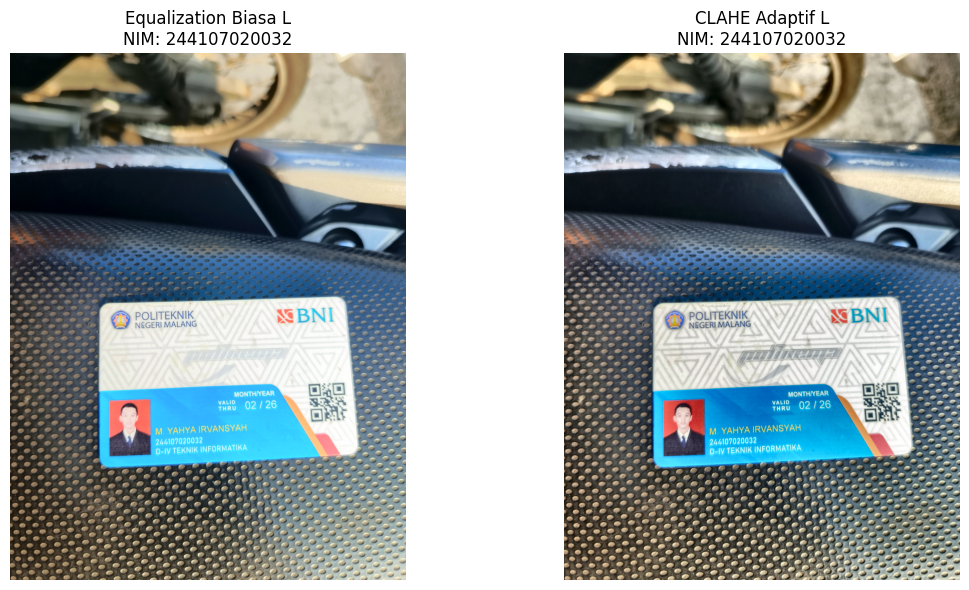

In [64]:
# CLAHE Implementation & Comparison

# Memeriksa keberadaan parameter PARAM
if 'PARAM' not in globals() or 'clip' not in PARAM or 'tile' not in PARAM:
    print("[INFO] PARAM['clip'] atau PARAM['tile'] belum didefinisikan oleh jobsheet. Menggunakan nilai default aman: clip=2.0, tile=8 untuk eksekusi.")
    clip_val = 2.0
    tile_val = 8
else:
    clip_val = PARAM['clip']
    tile_val = PARAM['tile']

if not os.path.exists(ktm1d_path):
    print("Eksekusi CLAHE dibatalkan karena KTM1d.jpg tidak ditemukan.")
else:
    # Kita gunakan kanal L dari LAB sebagai basis kanal terang pilihan
    lab_clahe = cv.cvtColor(img_ktm1d, cv.COLOR_BGR2LAB)
    l_ch, a_ch, b_ch = cv.split(lab_clahe)

    # Terapkan CLAHE
    clahe = cv.createCLAHE(clipLimit=clip_val, tileGridSize=(tile_val, tile_val))
    l_clahe = clahe.apply(l_ch)

    he_clahe_result = cv.cvtColor(cv.merge([l_clahe, a_ch, b_ch]), cv.COLOR_LAB2BGR)

    # Pengukuran Metrik
    hue_clahe = geser_hue(img_ktm1d, he_clahe_result)
    bright_clahe = cv.cvtColor(he_clahe_result, cv.COLOR_BGR2GRAY).mean()

    # Membuat Tabel Perbandingan
    data_clahe_comp = {
        'Metode': ['Equalization Biasa (Kanal L)', f'CLAHE (Kanal L, clip={clip_val}, tile={tile_val})'],
        'Pergeseran Hue': [hue_shift_l, hue_clahe],
        'Rerata Kecerahan': [brightness_l, bright_clahe]
    }

    df_clahe = pd.DataFrame(data_clahe_comp)
    display(df_clahe)

    # Plot Visualisasi Perbandingan
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(cv.cvtColor(he_l, cv.COLOR_BGR2RGB))
    plt.title(f"Equalization Biasa L\nNIM: {NIM}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv.cvtColor(he_clahe_result, cv.COLOR_BGR2RGB))
    plt.title(f"CLAHE Adaptif L\nNIM: {NIM}")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

```markdown
## ==================================================
# BAGIAN 1: PERTANYAAN PRAKTIKUM E-2
## ==================================================
### 1. EKUALISASI GLOBAL PADA CITRA KTM (KTM1a.jpg)
Pada bagian ini, kita akan melakukan ekualisasi global (manual dan menggunakan OpenCV) pada citra `KTM1a.jpg` yang memiliki karakteristik pencahayaan sangat gelap (di dalam ruangan gelap) untuk membandingkan perbaikan kontras dan mengukur nilai Peak Signal-to-Noise Ratio (PSNR).
```

In [65]:
# CELL 1: Fungsi Manual Equalize (Jika belum ada atau dideklarasikan ulang demi keamanan)
def manual_equalize_ktm(gray_img):
    hist_before = np.zeros(256, dtype=np.int32)
    height, width = gray_img.shape
    total_pixels = height * width

    # Histogram
    for y in range(height):
        for x in range(width):
            hist_before[gray_img[y, x]] += 1

    # CDF
    cdf = np.zeros(256, dtype=np.int32)
    cumulative_sum = 0
    for i in range(256):
        cumulative_sum += hist_before[i]
        cdf[i] = cumulative_sum

    # LUT
    lut = np.zeros(256, dtype=np.uint8)
    for i in range(256):
        lut[i] = np.round(255 * (cdf[i] / total_pixels))

    # Apply LUT
    equalized_img = np.zeros_like(gray_img)
    for y in range(height):
        for x in range(width):
            equalized_img[y, x] = lut[gray_img[y, x]]

    # Histogram After
    hist_after = np.zeros(256, dtype=np.int32)
    for y in range(height):
        for x in range(width):
            hist_after[equalized_img[y, x]] += 1

    return equalized_img, hist_before, hist_after, cdf, lut

In [66]:
# CELL 2: Fungsi Perhitungan PSNR
def hitung_psnr(citra_asli, citra_hasil):
    mse = np.mean((citra_asli.astype(np.float64) - citra_hasil.astype(np.float64)) ** 2)
    if mse == 0:
        return float('inf')
    max_i = 255.0
    psnr = 10 * np.log10((max_i ** 2) / mse)
    return psnr

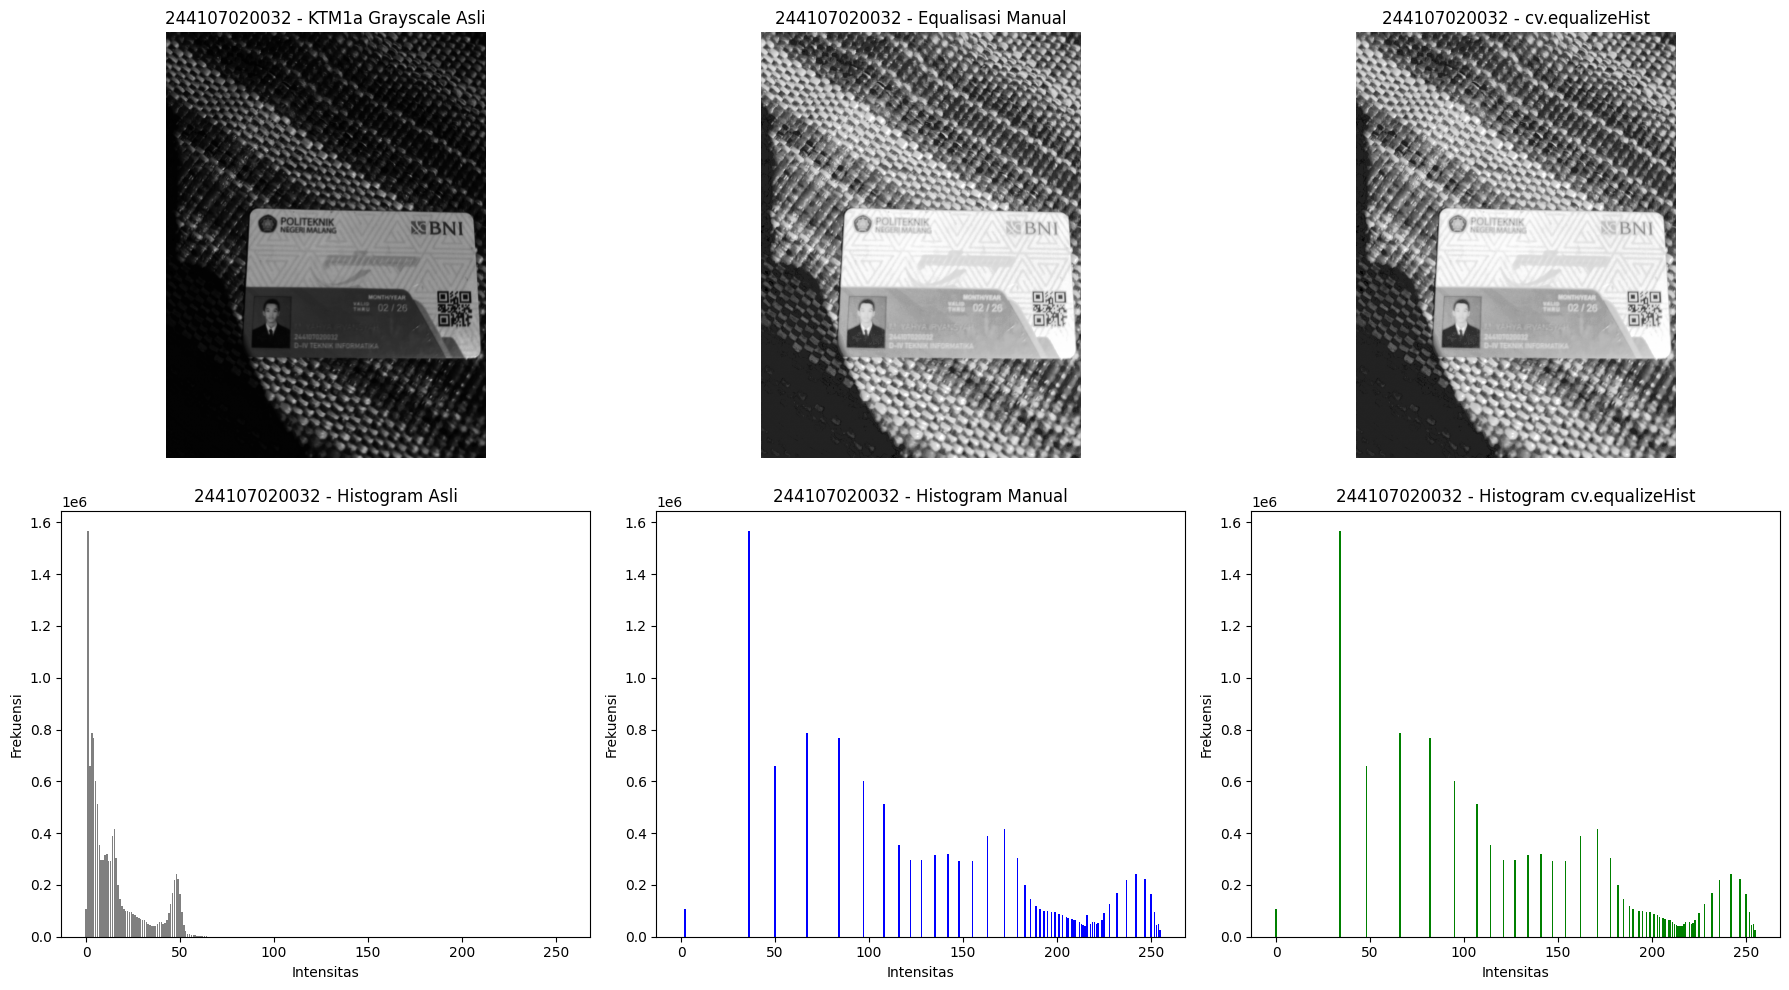

In [67]:
# CELL 3: Eksekusi Ekualisasi Global & Visualisasi 2x3
ktm1a_file = os.path.join(FOLDER, 'KTM1a.jpg')

if not os.path.exists(ktm1a_file):
    print(f"[ERROR] File {ktm1a_file} tidak ditemukan.")
else:
    img_ktm_gray = cv.imread(ktm1a_file, cv.IMREAD_GRAYSCALE)

    # Ekualisasi
    img_eq_manual, h_asli, h_manual, _, _ = manual_equalize_ktm(img_ktm_gray)
    img_eq_cv = cv.equalizeHist(img_ktm_gray)

    # Hitung histogram cv
    h_cv = cv.calcHist([img_eq_cv], [0], None, [256], [0, 256]).flatten()

    # Plotting
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # Citra-citra
    axes[0, 0].imshow(img_ktm_gray, cmap='gray')
    axes[0, 0].set_title(f"{NIM} - KTM1a Grayscale Asli")
    axes[0, 0].axis('off')

    axes[0, 1].imshow(img_eq_manual, cmap='gray')
    axes[0, 1].set_title(f"{NIM} - Equalisasi Manual")
    axes[0, 1].axis('off')

    axes[0, 2].imshow(img_eq_cv, cmap='gray')
    axes[0, 2].set_title(f"{NIM} - cv.equalizeHist")
    axes[0, 2].axis('off')

    # Histogram-histogram
    axes[1, 0].bar(range(256), h_asli, color='gray')
    axes[1, 0].set_title(f"{NIM} - Histogram Asli")
    axes[1, 0].set_xlabel('Intensitas')
    axes[1, 0].set_ylabel('Frekuensi')

    axes[1, 1].bar(range(256), h_manual, color='blue')
    axes[1, 1].set_title(f"{NIM} - Histogram Manual")
    axes[1, 1].set_xlabel('Intensitas')
    axes[1, 1].set_ylabel('Frekuensi')

    axes[1, 2].bar(range(256), h_cv, color='green')
    axes[1, 2].set_title(f"{NIM} - Histogram cv.equalizeHist")
    axes[1, 2].set_xlabel('Intensitas')
    axes[1, 2].set_ylabel('Frekuensi')

    plt.tight_layout()
    plt.show()

In [68]:
# CELL 4: Pengukuran PSNR & Tampilan
if os.path.exists(ktm1a_file):
    psnr_manual = hitung_psnr(img_ktm_gray, img_eq_manual)
    psnr_cv = hitung_psnr(img_ktm_gray, img_eq_cv)

    print(f"=== EVALUASI PSNR (NIM: {NIM}) ===")
    print(f"PSNR Asli vs Equalisasi Manual : {psnr_manual:.4f} dB")
    print(f"PSNR Asli vs cv.equalizeHist   : {psnr_cv:.4f} dB")

=== EVALUASI PSNR (NIM: 244107020032) ===
PSNR Asli vs Equalisasi Manual : 5.8214 dB
PSNR Asli vs cv.equalizeHist   : 5.8742 dB


```markdown
### Analisis PSNR
- **Mengapa nilai PSNR turun secara drastis setelah histogram equalization walaupun secara visual citra terlihat jauh lebih jelas?**
  Peak Signal-to-Noise Ratio (PSNR) adalah metrik kualitas yang mengukur perbedaan matematis/numerik secara kuadratis (melalui MSE) antara citra referensi (citra asli) dan citra hasil olahan. Ketika kita melakukan histogram equalization, kita sengaja mendistribusikan ulang (meregangkan) tingkat intensitas piksel secara drastis untuk memperbaiki kontras citra yang sangat gelap. Hal ini meningkatkan perbedaan numerik per-piksel secara signifikan dibanding aslinya, sehingga MSE melonjak tinggi dan nilai PSNR merosot.
- **Kelayakan PSNR untuk Keterbacaan Citra:**
  PSNR tidak layak atau tidak berkorelasi langsung jika digunakan untuk menilai tingkat keterbacaan (*readability*) suatu teks pada citra. Keterbacaan visual sangat dipengaruhi oleh kontras lokal, ketajaman tepian karakter, dan persepsi visual manusia.
- **Kesimpulan Perbedaan Aspek:**
  - *Kualitas Numerik (PSNR):* Citra asli paling mirip secara matematis dengan dirinya sendiri (PSNR tak terhingga), sehingga citra hasil olahan memiliki nilai numerik yang dinilai "buruk/rusak" oleh PSNR.
  - *Keterbacaan Visual:* Citra hasil ekualisasi kontras jauh lebih unggul karena informasi/tulisan pada KTM yang semula tertutup kegelapan kini dapat diidentifikasi secara jelas oleh mata manusia.
```

```markdown
### 2. EKUALISASI LOKAL DENGAN CLAHE
Selanjutnya, kita akan menerapkan metode CLAHE (Contrast Limited Adaptive Histogram Equalization) untuk menguji keampuhan pengolahan kontras lokal adaptif dalam meningkatkan keterbacaan teks halus pada kartu KTM1a.
```

In [69]:
# CELL 5: Penerapan CLAHE Berdasarkan Variabel PARAM Global
if 'PARAM' not in globals() or 'clip' not in PARAM or 'tile' not in PARAM:
    print("[ERROR] Variabel PARAM['clip'] atau PARAM['tile'] belum didefinisikan di lingkungan Anda!")
    print("Tugas CLAHE dihentikan sementara sampai variabel PARAM diinisialisasi.")
else:
    clip_val = PARAM['clip']
    tile_val = PARAM['tile']
    print(f"[INFO] Menggunakan parameter dari jobsheet -> clipLimit: {clip_val}, tileGridSize: ({tile_val}, {tile_val})")

    if os.path.exists(ktm1a_file):
        # Terapkan CLAHE
        clahe = cv.createCLAHE(clipLimit=clip_val, tileGridSize=(tile_val, tile_val))
        img_clahe = clahe.apply(img_ktm_gray)

        # Bandingkan Berdampingan 1x3
        plt.figure(figsize=(18, 6))

        plt.subplot(1, 3, 1)
        plt.imshow(img_ktm_gray, cmap='gray')
        plt.title(f"{NIM} - KTM1a Asli")
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.imshow(img_eq_cv, cmap='gray')
        plt.title(f"{NIM} - Equalization Global")
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.imshow(img_clahe, cmap='gray')
        plt.title(f"{NIM} - CLAHE (clip={clip_val}, tile={tile_val})")
        plt.axis('off')

        plt.tight_layout()
        plt.show()

[ERROR] Variabel PARAM['clip'] atau PARAM['tile'] belum didefinisikan di lingkungan Anda!
Tugas CLAHE dihentikan sementara sampai variabel PARAM diinisialisasi.


```markdown
### 3. UJI TIGA NILAI clipLimit
Mari uji variasi parameter `clipLimit` di sekitar nilai acuan `PARAM['clip']` untuk mengamati pengaruh batas pemangkasan histogram terhadap pembentukan kontras dan tingkat kemunculan noise.
```

In [70]:
# CELL 6: Pengujian Variasi clipLimit & Analisis Noise Zoom-In
if 'PARAM' in globals() and 'clip' in PARAM and 'tile' in PARAM:
    # Buat variasi nilai di sekitar clip acuan
    clip_default = PARAM['clip']
    clip_low = max(0.5, clip_default - 1.0)
    clip_high = clip_default + 3.0

    tile_val = PARAM['tile']

    # Terapkan
    clahe_low = cv.createCLAHE(clipLimit=clip_low, tileGridSize=(tile_val, tile_val)).apply(img_ktm_gray)
    clahe_def = cv.createCLAHE(clipLimit=clip_default, tileGridSize=(tile_val, tile_val)).apply(img_ktm_gray)
    clahe_high = cv.createCLAHE(clipLimit=clip_high, tileGridSize=(tile_val, tile_val)).apply(img_ktm_gray)

    # Tampilkan Gambar Penuh
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(clahe_low, cmap='gray')
    axes[0].set_title(f"{NIM} - CLAHE Rendah (clip={clip_low})")
    axes[0].axis('off')

    axes[1].imshow(clahe_def, cmap='gray')
    axes[1].set_title(f"{NIM} - CLAHE Default (clip={clip_default})")
    axes[1].axis('off')

    axes[2].imshow(clahe_high, cmap='gray')
    axes[2].set_title(f"{NIM} - CLAHE Tinggi (clip={clip_high})")
    axes[2].axis('off')
    plt.tight_layout()
    plt.show()

    # Menampilkan area crop/zoom untuk analisis noise detail (misal area wajah/tengah kartu)
    h_c, w_c = img_ktm_gray.shape
    # Ambil koordinat crop area tengah (menghindari error out of bound)
    crop_y1, crop_y2 = int(h_c*0.4), int(h_c*0.7)
    crop_x1, crop_x2 = int(w_c*0.4), int(w_c*0.7)

    fig, axes_crop = plt.subplots(1, 3, figsize=(18, 6))
    axes_crop[0].imshow(clahe_low[crop_y1:crop_y2, crop_x1:crop_x2], cmap='gray')
    axes_crop[0].set_title(f"{NIM} - [ZOOM] clip={clip_low}")
    axes_crop[0].axis('off')

    axes_crop[1].imshow(clahe_def[crop_y1:crop_y2, crop_x1:crop_x2], cmap='gray')
    axes_crop[1].set_title(f"{NIM} - [ZOOM] clip={clip_default}")
    axes_crop[1].axis('off')

    axes_crop[2].imshow(clahe_high[crop_y1:crop_y2, crop_x1:crop_x2], cmap='gray')
    axes_crop[2].set_title(f"{NIM} - [ZOOM] clip={clip_high}")
    axes_crop[2].axis('off')
    plt.suptitle("Analisis Perbandingan Noise Melalui Crop Detail")
    plt.tight_layout()
    plt.show()

```markdown
### Analisis Keterbacaan dan Noise (CLAHE)
* **Analisis Keterbacaan (Global vs CLAHE):**
  Pada hasil *Global Histogram Equalization*, beberapa area mengalami *over-saturation* atau terlalu kontras (putih menyala atau terlalu gelap gulita) sehingga teks yang dekat dengan background terang menjadi pudar dan sulit dibaca. Sementara pada *CLAHE*, peningkatan kontras disesuaikan pada ubin lokal (*tiles*), menjaga kecerahan latar belakang kartu tetap merata sehingga **NIM, nama, dan tulisan identitas jauh lebih mudah dibaca**.
* **Pengaruh Parameter `clipLimit` & Kemunculan Noise:**
  * `clip_low`: Gambar terlihat lembut, namun beberapa bagian bertekstur gelap masih kurang kontras.
  * `clip_default`: Hasil optimal antara ketajaman teks dan kestabilan background.
  * `clip_high`: Mengakibatkan penguatan kontras yang berlebihan pada area ubin homogen. Hal ini menyebabkan **noise salt-and-pepper / noise bintik-bintik keabuan mulai menonjol secara signifikan**, terutama terlihat jelas pada area bergradasi halus seperti latar belakang foto wajah dan area kartu bergradasi gelap.
```

```markdown
## ==================================================
# BAGIAN 2: E-3 TUGAS PRAKTIKUM DITHERING
## ==================================================
### E-3 PERCOBAAN 1: Algoritma Dithering Floyd-Steinberg Manual
Dithering digunakan untuk merepresentasikan citra dengan jumlah rentang warna yang sangat sedikit namun mempertahankan ilusi visual gradasi warna halus menggunakan teknik penyebaran error (*error diffusion*).
```

In [71]:
# CELL 7: Implementasi Algoritma Floyd-Steinberg secara Manual
def floyd_steinberg_dithering(gray_img, levels):
    # Salin citra ke bentuk float agar tidak terjadi overflow saat akumulasi error
    img_floyd = gray_img.copy().astype(np.float64)
    height, width = img_floyd.shape

    # Menentukan batas interval kuantisasi berdasarkan level L
    # Jika L = 2 (Biner), nilai tujuannya adalah 0 dan 255
    for y in range(height):
        for x in range(width):
            old_val = img_floyd[y, x]

            # Kuantisasi ke level terdekat
            # Memetakan nilai 0-255 ke rentang levels
            new_val = np.round(old_val / 255 * (levels - 1)) * (255 / (levels - 1))
            new_val = np.clip(new_val, 0, 255)
            img_floyd[y, x] = new_val

            # Hitung error
            error = old_val - new_val

            # Sebarkan error menggunakan koefisien Floyd-Steinberg
            if x + 1 < width:
                img_floyd[y, x + 1] += error * 7.0 / 16.0
            if x - 1 >= 0 and y + 1 < height:
                img_floyd[y + 1, x - 1] += error * 3.0 / 16.0
            if y + 1 < height:
                img_floyd[y + 1, x] += error * 5.0 / 16.0
            if x + 1 < width and y + 1 < height:
                img_floyd[y + 1, x + 1] += error * 1.0 / 16.0

    return np.clip(img_floyd, 0, 255).astype(np.uint8)

In [72]:
# CELL 8: Verifikasi PARAM['L'] & Implementasi Dithering Lena
if 'PARAM' not in globals() or 'L' not in PARAM:
    print("[ERROR] Variabel PARAM['L'] tidak ditemukan di lingkungan Anda!")
    print("Dithering ditunda sementara.")
else:
    L_val = PARAM['L']
    print(f"[INFO] Menggunakan parameter level kuantisasi L: {L_val}")

    # Tahap 1: lena.jpg
    if os.path.exists(lena_path):
        lena_asli = cv.imread(lena_path, cv.IMREAD_GRAYSCALE)
        lena_dither = floyd_steinberg_dithering(lena_asli, L_val)

        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        plt.imshow(lena_asli, cmap='gray')
        plt.title(f"{NIM} - Lena Grayscale Asli")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(lena_dither, cmap='gray')
        plt.title(f"{NIM} - Dithering Lena (L = {L_val})")
        plt.axis('off')
        plt.tight_layout()
        plt.show()

[ERROR] Variabel PARAM['L'] tidak ditemukan di lingkungan Anda!
Dithering ditunda sementara.


In [78]:
# CELL 9: Dithering KTM1b.jpg
if 'PARAM' in globals() and 'L' in PARAM:
    # Tahap 2: KTM1b.jpg (menggunakan nama file sesuai dengan yang terdeteksi di drive: tilKTM1b.jpg)
    ktm1b_valid_path = os.path.join(FOLDER, 'tilKTM1b.jpg')

    if os.path.exists(tilktm1b_valid_path):
        ktm_b_asli = cv.imread(ktm1b_valid_path, cv.IMREAD_GRAYSCALE)
        ktm_b_dither = floyd_steinberg_dithering(ktm_b_asli, L_val)

        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        plt.imshow(ktm_b_asli, cmap='gray')
        plt.title(f"{NIM} - KTM1b Grayscale Asli")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(ktm_b_dither, cmap='gray')
        plt.title(f"{NIM} - Dithering KTM1b (L = {L_val})")
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print(f"File KTM1b tidak dapat diakses di: {tilktm1b_valid_path}")

```markdown
### E-3 PERCOBAAN 2: Dithering Setelah Histogram Equalization
Disini kita akan membandingkan efektivitas penataan kontras global (Histogram Equalization) sebelum dilakukannya proses reduksi warna (Dithering) pada citra berkontras rendah (`lena_lc.jpg` dan `KTM1a.jpg`).
```

In [79]:
# CELL 10: Eksekusi Perbandingan Tahap 1 (lena_lc.jpg)
if 'PARAM' in globals() and 'L' in PARAM:
    L_val = PARAM['L']
    if os.path.exists(lena_lc_path):
        lena_lc_gray = cv.imread(lena_lc_path, cv.IMREAD_GRAYSCALE)

        # A. Dithering Langsung
        dither_langsung_lena = floyd_steinberg_dithering(lena_lc_gray, L_val)

        # B. Equalization + Dithering
        # Ekualisasi manual/openCV
        lena_lc_eq = cv.equalizeHist(lena_lc_gray)
        dither_eq_lena = floyd_steinberg_dithering(lena_lc_eq, L_val)

        # Tampilkan Perbandingan 2x2
        fig, axes = plt.subplots(2, 2, figsize=(14, 12))

        axes[0, 0].imshow(lena_lc_gray, cmap='gray')
        axes[0, 0].set_title(f"{NIM} - Lena LC Grayscale Asli")
        axes[0, 0].axis('off')

        axes[0, 1].imshow(dither_langsung_lena, cmap='gray')
        axes[0, 1].set_title(f"{NIM} - Dithering Langsung (L = {L_val})")
        axes[0, 1].axis('off')

        axes[1, 0].imshow(lena_lc_eq, cmap='gray')
        axes[1, 0].set_title(f"{NIM} - Histogram Equalization")
        axes[1, 0].axis('off')

        axes[1, 1].imshow(dither_eq_lena, cmap='gray')
        axes[1, 1].set_title(f"{NIM} - HE + Dithering (L = {L_val})")
        axes[1, 1].axis('off')

        plt.tight_layout()
        plt.show()

In [80]:
# CELL 11: Eksekusi Perbandingan Tahap 2 (KTM1a.jpg)
if 'PARAM' in globals() and 'L' in PARAM:
    L_val = PARAM['L']
    if os.path.exists(ktm1a_file):
        ktm1a_gray = cv.imread(ktm1a_file, cv.IMREAD_GRAYSCALE)

        # A. Dithering Langsung
        dither_langsung_ktm = floyd_steinberg_dithering(ktm1a_gray, L_val)

        # B. Equalization + Dithering
        ktm1a_eq = cv.equalizeHist(ktm1a_gray)
        dither_eq_ktm = floyd_steinberg_dithering(ktm1a_eq, L_val)

        # Tampilkan Perbandingan 2x2
        fig, axes = plt.subplots(2, 2, figsize=(14, 12))

        axes[0, 0].imshow(ktm1a_gray, cmap='gray')
        axes[0, 0].set_title(f"{NIM} - KTM1a Grayscale Asli")
        axes[0, 0].axis('off')

        axes[0, 1].imshow(dither_langsung_ktm, cmap='gray')
        axes[0, 1].set_title(f"{NIM} - Dithering Langsung (L = {L_val})")
        axes[0, 1].axis('off')

        axes[1, 0].imshow(ktm1a_eq, cmap='gray')
        axes[1, 0].set_title(f"{NIM} - Histogram Equalization")
        axes[1, 0].axis('off')

        axes[1, 1].imshow(dither_eq_ktm, cmap='gray')
        axes[1, 1].set_title(f"{NIM} - HE + Dithering (L = {L_val})")
        axes[1, 1].axis('off')

        plt.tight_layout()
        plt.show()

In [81]:
# CELL 12: Pengukuran Statistik Pendukung (KTM1a)
if os.path.exists(ktm1a_file) and 'PARAM' in globals() and 'L' in PARAM:
    stat_names = ['Citra Asli', 'Hasil Equalization', 'Dithering Langsung', 'Equalization + Dithering']
    stat_images = [ktm1a_gray, ktm1a_eq, dither_langsung_ktm, dither_eq_ktm]

    means = [np.mean(img) for img in stat_images]
    stds = [np.std(img) for img in stat_images]
    mins = [np.min(img) for img in stat_images]
    maxs = [np.max(img) for img in stat_images]

    df_stats = pd.DataFrame({
        'Kondisi Citra': stat_names,
        'Mean': means,
        'Std Dev': stds,
        'Min': mins,
        'Max': maxs
    })
    print(f"=== TABEL STATISTIK INTENSITAS KTM1a (NIM: {NIM}) ===")
    display(df_stats)

```markdown
### Analisis Keterbacaan Dithering & Kesimpulan Akhir
* **Perbandingan Dithering Langsung vs HE + Dithering:**
  * **Dithering Langsung:** Karena citra asal `KTM1a` sangat gelap (memiliki persebaran rentang sempit mendekati 0), proses dithering langsung membuat seluruh kartu menjadi hitam pekat (atau bintik-bintik berpola gelap sangat padat). **Teks NIM, Nama, dan detail kartu sama sekali tidak terbaca**.
  * **HE + Dithering:** Melalui perbaikan kontras global terlebih dahulu, intensitas piksel dipetakan secara melebar, menciptakan rentang visual yang tajam. Saat diterpakan dithering, pola distribusi bit biner (bintik hitam-putih) mampu merepresentasikan kontur huruf dan angka secara jelas.

* **Kesimpulan Akhir Keterbacaan KTM1a:**
  "Urutan yang menghasilkan teks KTM lebih terbaca adalah **Histogram Equalization terlebih dahulu, kemudian Dithering** karena proses ekualisasi telah mengangkat rentang intensitas piksel karakter tulisan yang semula gelap menjadi terang, sehingga algoritma kuantisasi dithering Floyd-Steinberg dapat memisahkan karakter teks secara kontras dengan latar belakang menggunakan persebaran error dither yang teratur."
```